In [1]:
from pathlib import Path

DATA_DIR = Path("../data/raw/animals")

print("Dataset exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR.resolve())

Dataset exists: True
Dataset path: C:\Users\prate\OneDrive\Desktop\DL Project\Data\raw\animals


In [2]:
classes = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

print("Number of species:", len(classes))
print(classes)

Number of species: 90
['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker', 'zebra']


In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

class_counts = {}

for class_name in classes:
    class_dir = DATA_DIR / class_name

    images = [
        file for file in class_dir.iterdir()
        if file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    class_counts[class_name] = len(images)

print("Total images:", sum(class_counts.values()))
print("Minimum images/class:", min(class_counts.values()))
print("Maximum images/class:", max(class_counts.values()))

Total images: 5400
Minimum images/class: 60
Maximum images/class: 60


In [5]:
import pandas as pd

df = pd.DataFrame(
    class_counts.items(),
    columns=["species", "image_count"]
)

df.sort_values("image_count", ascending=False)

,species,image_count
0,antelope,60
1,badger,60
2,bat,60
3,bear,60
4,bee,60
...,...,...
85,whale,60
86,wolf,60
87,wombat,60
88,woodpecker,60


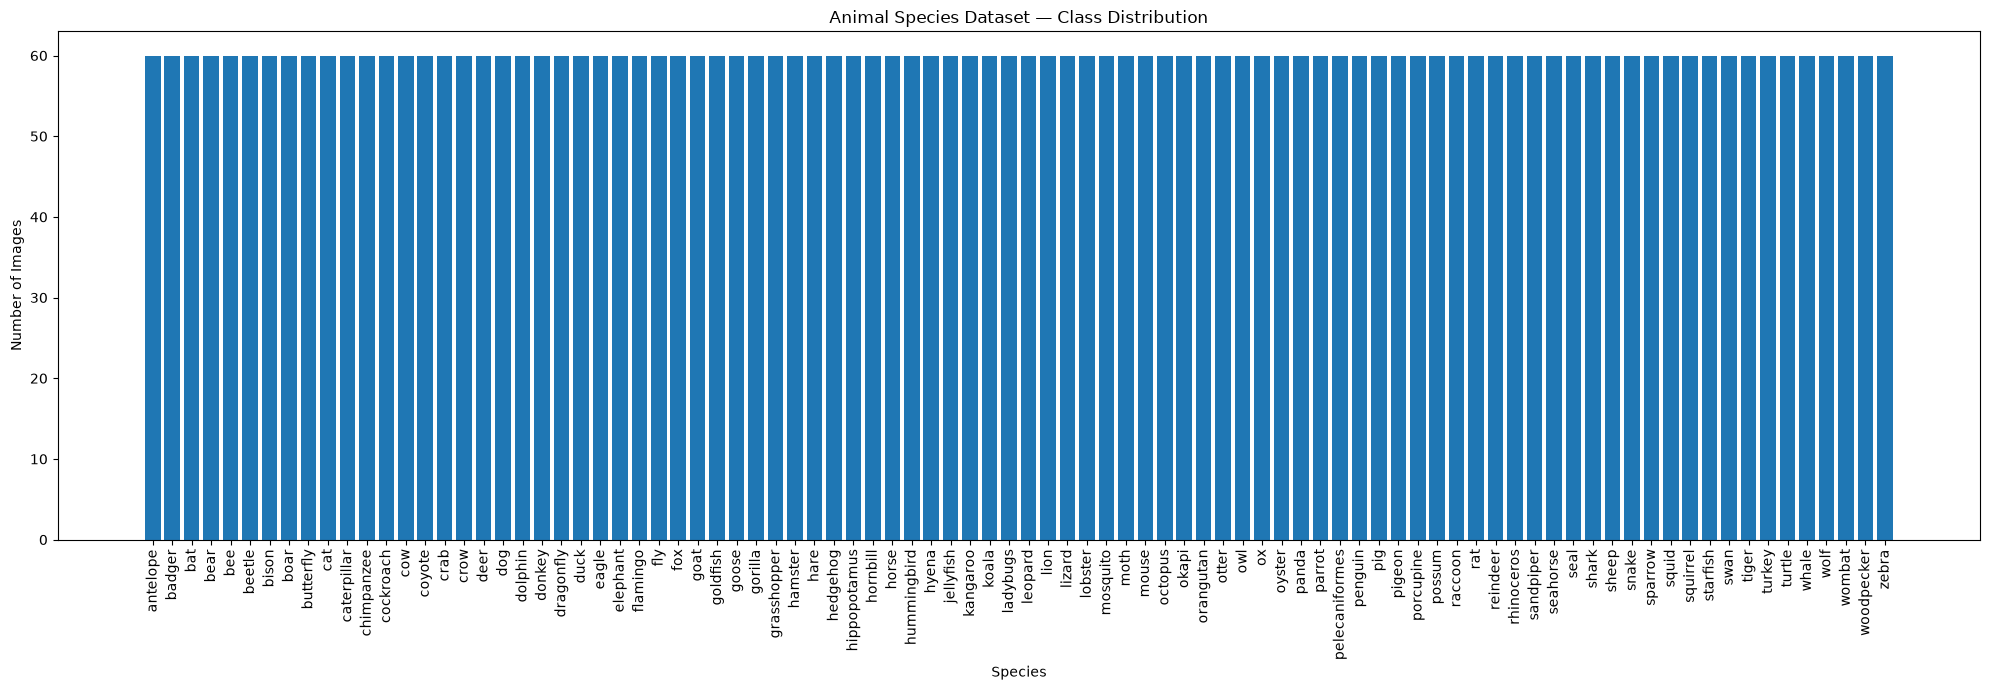

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 7))

plt.bar(df["species"], df["image_count"])

plt.xlabel("Species")
plt.ylabel("Number of Images")
plt.title("Animal Species Dataset — Class Distribution")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
from PIL import Image
from collections import Counter

DATA_DIR = Path("../data/raw/animals")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}
classes = sorted(
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
)

image_sizes = Counter()
image_modes = Counter()
corrupted_images = []

for class_name in classes:
    class_dir = DATA_DIR / class_name

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            with Image.open(image_path) as img:
                image_sizes[img.size] += 1
                image_modes[img.mode] += 1

        except Exception:
            corrupted_images.append(str(image_path))

print("Total corrupted images:", len(corrupted_images))

print("\nImage modes:")
print(image_modes)

print("\nMost common image sizes:")
for size, count in image_sizes.most_common(10):
    print(size, ":", count)

Total corrupted images: 0

Image modes:
Counter({'RGB': 5400})

Most common image sizes:
(275, 183) : 477
(300, 168) : 344
(259, 194) : 224
(225, 225) : 172
(299, 168) : 103
(1200, 900) : 62
(1200, 675) : 57
(310, 163) : 56
(1200, 800) : 55
(1200, 1200) : 53


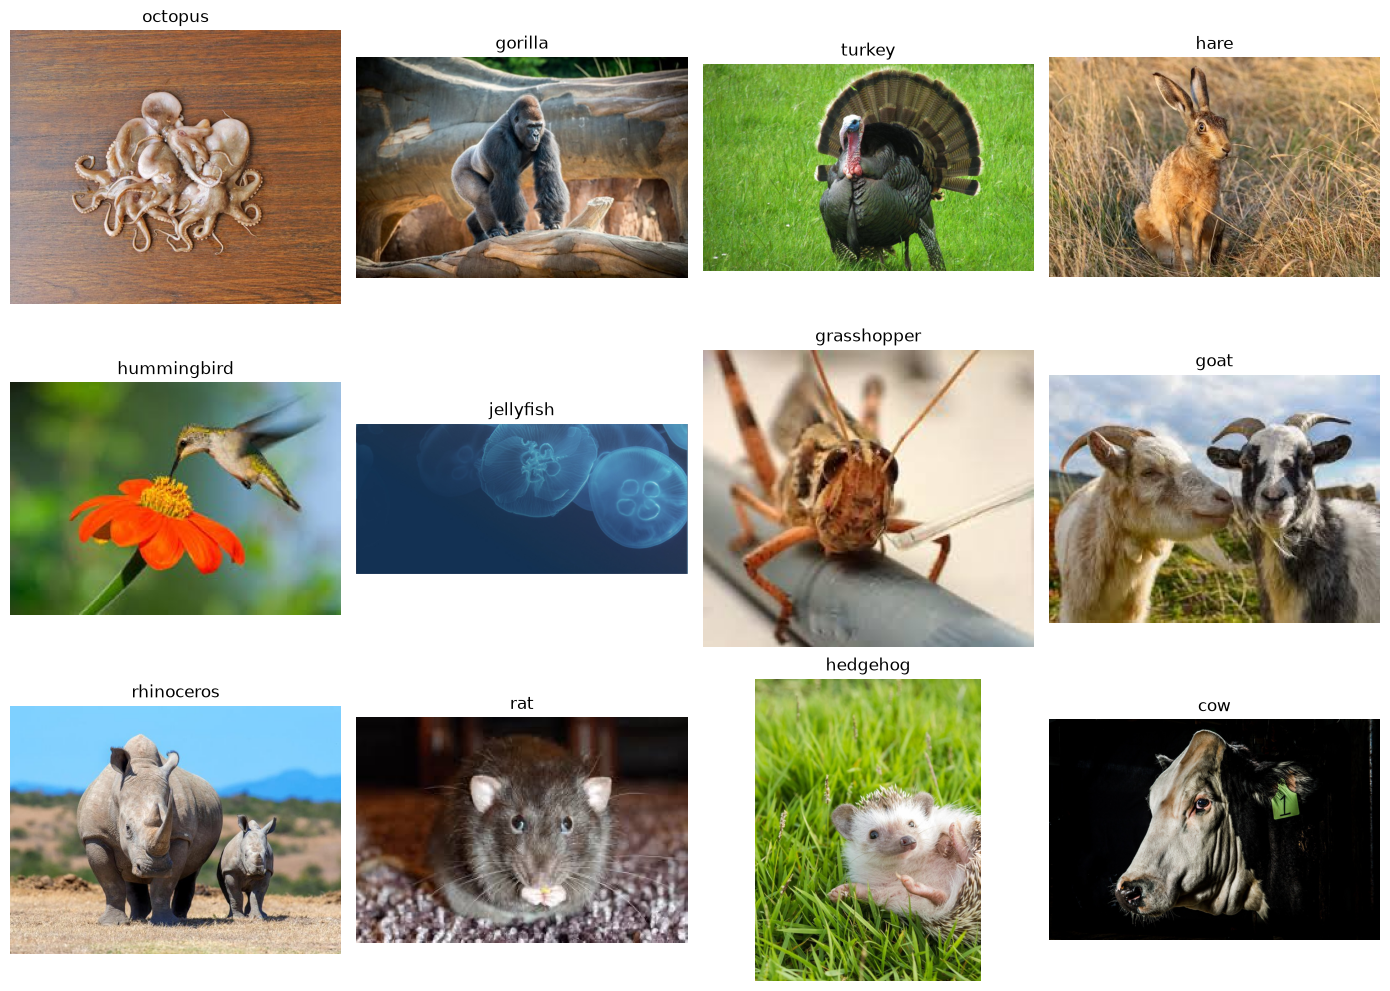

In [9]:
import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax in axes.flat:

    class_name = random.choice(classes)

    class_dir = DATA_DIR / class_name

    image_files = [
        f for f in class_dir.iterdir()
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_path = random.choice(image_files)

    img = Image.open(image_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
selected_classes = [
    "cat",
    "leopard",
    "lion",
    "tiger",
    "fox",
    "wolf",
    "bear",
    "panda",
    "deer",
    "antelope",
    "horse",
    "zebra"
]

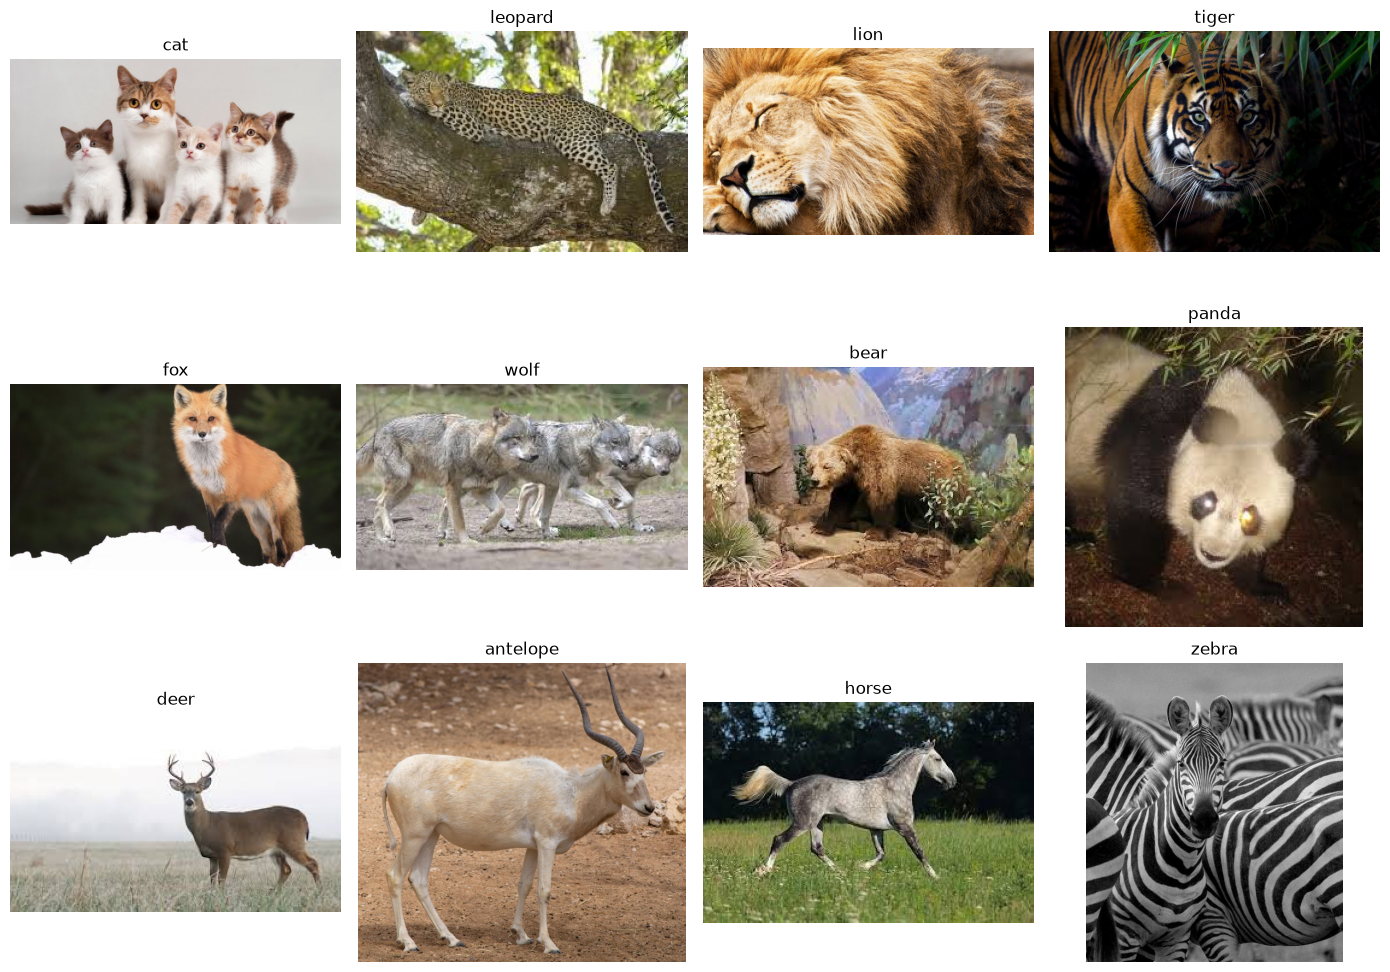

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, class_name in zip(axes.flat, selected_classes):

    class_dir = DATA_DIR / class_name

    image_files = [
        f for f in class_dir.iterdir()
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_path = random.choice(image_files)

    img = Image.open(image_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU count: 1


In [8]:
from pathlib import Path
from collections import Counter
from PIL import Image
import random
import matplotlib.pyplot as plt

# Dataset path
DATA_DIR = Path("../data/raw/animals")

# Image extensions
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

# Get all species/classes
classes = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

print("Dataset exists:", DATA_DIR.exists())
print("Number of species:", len(classes))
print("Total classes:")
print(classes)

Dataset exists: True
Number of species: 90
Total classes:
['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker', 'zebra']


In [9]:
image_sizes = Counter()
image_modes = Counter()
corrupted_images = []

for class_name in classes:
    class_dir = DATA_DIR / class_name

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            with Image.open(image_path) as img:
                image_sizes[img.size] += 1
                image_modes[img.mode] += 1

        except Exception as e:
            corrupted_images.append(str(image_path))

print("Total corrupted images:", len(corrupted_images))

print("\nImage modes:")
for mode, count in image_modes.items():
    print(f"{mode}: {count}")

print("\nMost common image sizes:")

for size, count in image_sizes.most_common(10):
    print(f"{size}: {count}")

Total corrupted images: 0

Image modes:
RGB: 5400

Most common image sizes:
(275, 183): 477
(300, 168): 344
(259, 194): 224
(225, 225): 172
(299, 168): 103
(1200, 900): 62
(1200, 675): 57
(310, 163): 56
(1200, 800): 55
(1200, 1200): 53


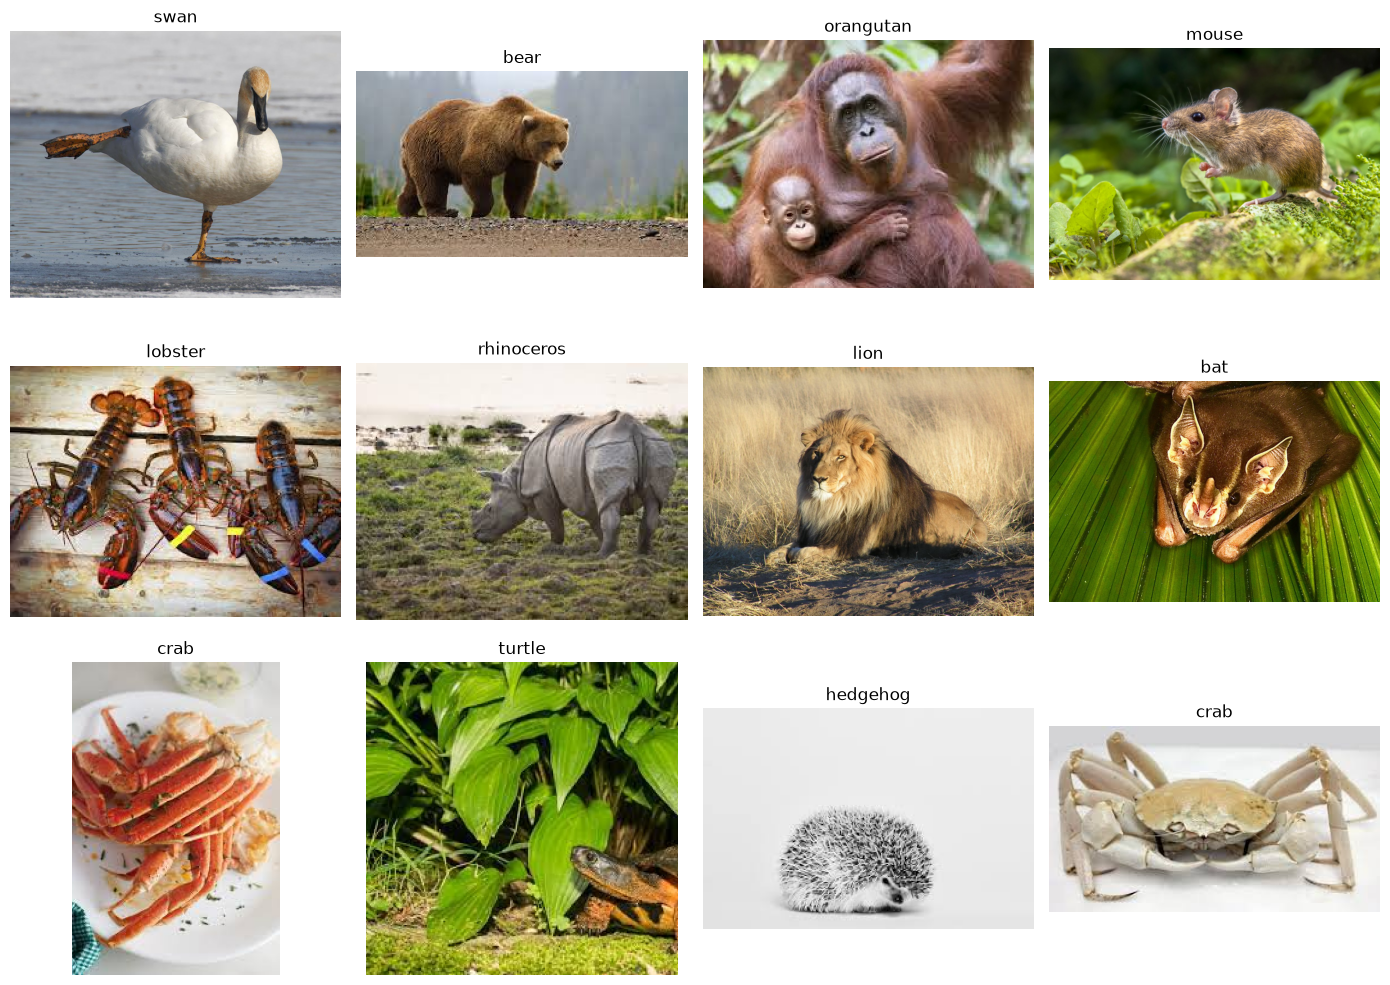

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax in axes.flat:

    class_name = random.choice(classes)

    class_dir = DATA_DIR / class_name

    image_files = [
        f for f in class_dir.iterdir()
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_path = random.choice(image_files)

    img = Image.open(image_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Training

In [11]:
from sklearn.model_selection import train_test_split
import shutil
import random

# Set seed for reproducibility
random.seed(42)

# Output directories
PROCESSED_DIR = Path("../data/processed")

TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR = PROCESSED_DIR / "val"
TEST_DIR = PROCESSED_DIR / "test"

# Create directories
for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Directories created.")

Directories created.


In [12]:
for class_name in classes:

    class_dir = DATA_DIR / class_name

    images = [
        f for f in class_dir.iterdir()
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # First: 80% train, 20% temporary
    train_images, temp_images = train_test_split(
        images,
        test_size=0.20,
        random_state=42
    )

    # Then: split temporary into 10% validation + 10% test
    val_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=42
    )

    # Create class directories
    train_class_dir = TRAIN_DIR / class_name
    val_class_dir = VAL_DIR / class_name
    test_class_dir = TEST_DIR / class_name

    train_class_dir.mkdir(parents=True, exist_ok=True)
    val_class_dir.mkdir(parents=True, exist_ok=True)
    test_class_dir.mkdir(parents=True, exist_ok=True)

    # Copy files
    for image in train_images:
        shutil.copy2(image, train_class_dir / image.name)

    for image in val_images:
        shutil.copy2(image, val_class_dir / image.name)

    for image in test_images:
        shutil.copy2(image, test_class_dir / image.name)

print("Dataset split completed!")

Dataset split completed!


In [13]:
def count_images(directory):

    counts = {}

    for class_dir in directory.iterdir():

        if class_dir.is_dir():

            counts[class_dir.name] = len([
                f for f in class_dir.iterdir()
                if f.suffix.lower() in IMAGE_EXTENSIONS
            ])

    return counts


train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("TRAIN")
print("Total:", sum(train_counts.values()))
print("Min:", min(train_counts.values()))
print("Max:", max(train_counts.values()))

print("\nVALIDATION")
print("Total:", sum(val_counts.values()))
print("Min:", min(val_counts.values()))
print("Max:", max(val_counts.values()))

print("\nTEST")
print("Total:", sum(test_counts.values()))
print("Min:", min(test_counts.values()))
print("Max:", max(test_counts.values()))

TRAIN
Total: 4320
Min: 48
Max: 48

VALIDATION
Total: 540
Min: 6
Max: 6

TEST
Total: 540
Min: 6
Max: 6


In [14]:
print("Train classes:", len(train_counts))
print("Validation classes:", len(val_counts))
print("Test classes:", len(test_counts))

print(
    "All classes present:",
    set(classes) == set(train_counts) == set(val_counts) == set(test_counts)
)

Train classes: 90
Validation classes: 90
Test classes: 90
All classes present: True
